# Day 6 – Random Forest Forecasting

## Objective

Today we'll build a Random Forest forecasting model and compare it with Linear Regression.

Steps

- Load feature dataset
- Train Random Forest
- Evaluate performance
- Visualize predictions
- Save model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
forecast_df = pd.read_csv(
    "../data/processed/forecast_features.csv"
)

forecast_df["Order Date"] = pd.to_datetime(
    forecast_df["Order Date"]
)

print("Dataset loaded.")

print(forecast_df.shape)

forecast_df.head()

Dataset loaded.
(1200, 15)


,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2015-02-14,576.726,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015-02-15,21.360,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015-02-16,9.040,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015-02-17,54.208,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015-02-18,37.784,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


In [3]:
X = forecast_df.drop(
    columns=[
        "Order Date",
        "Sales"
    ]
)

y = forecast_df["Sales"]

print(X.shape)
print(y.shape)

X.head()

(1200, 13)
(1200,)


,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(960, 13)
(240, 13)


In [8]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [9]:
predictions = model.predict(X_test)

print(predictions[:10])

[4284.66159077 3931.14557075 1036.44246828 1608.80596628 1302.1351583
 2730.12830628 1866.10572645  690.68020038  799.13261474 3117.43315421]


In [10]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.4f}")

MAE : 1367.22
RMSE : 2451.95
R² : 0.1455


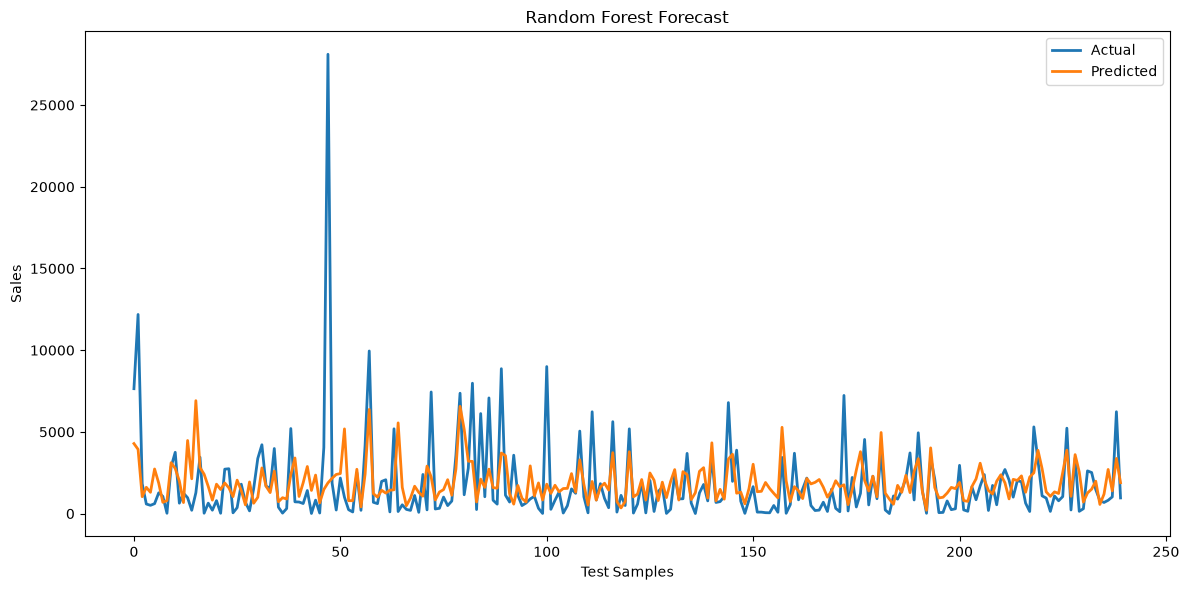

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    predictions,
    label="Predicted",
    linewidth=2
)

plt.title("Random Forest Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

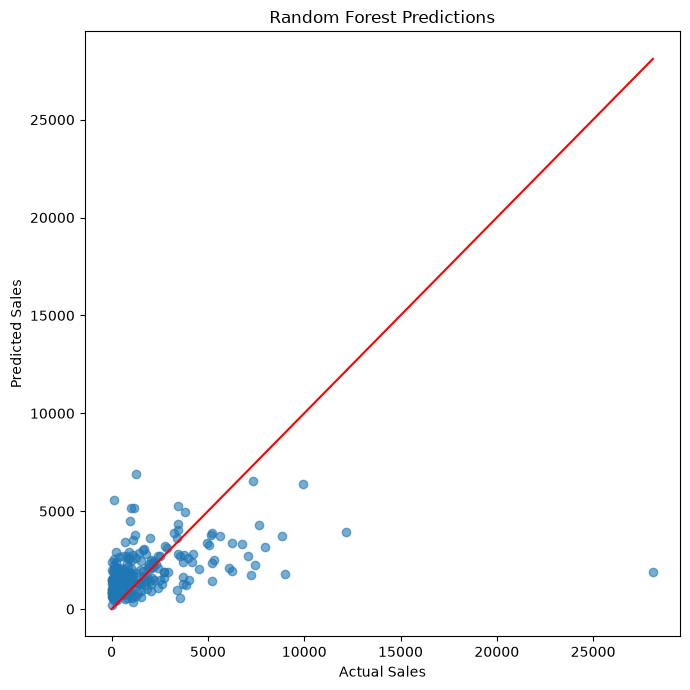

In [12]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Random Forest Predictions")

plt.tight_layout()

plt.show()

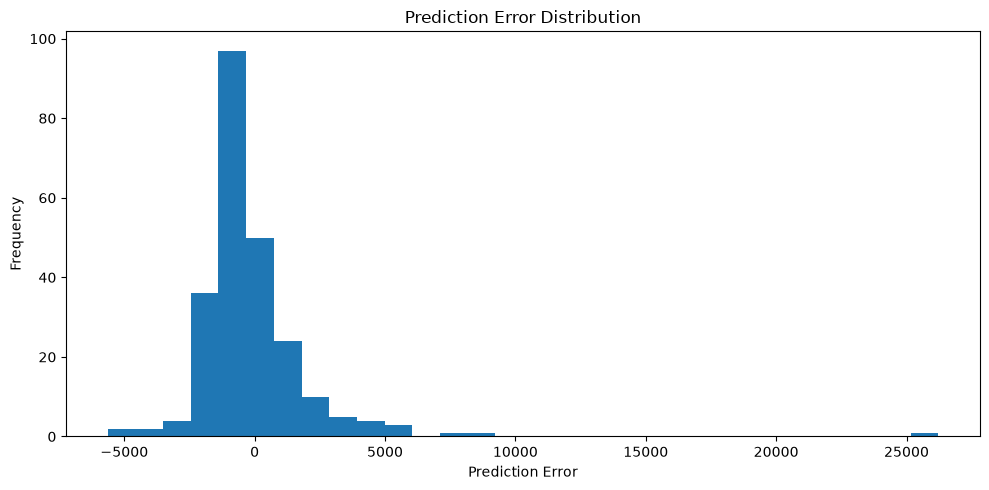

In [13]:
errors = y_test - predictions

plt.figure(figsize=(10,5))

plt.hist(
    errors,
    bins=30
)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [14]:
# Actual vs Predicted

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Random Forest Forecast")
plt.tight_layout()

plt.savefig("../charts/random_forest_forecast.png")
plt.close()


# Scatter Plot

plt.figure(figsize=(7,7))
plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Random Forest Scatter")
plt.tight_layout()

plt.savefig("../charts/random_forest_scatter.png")
plt.close()


# Error Distribution

plt.figure(figsize=(10,5))
plt.hist(errors, bins=30)

plt.title("Random Forest Error Distribution")
plt.tight_layout()

plt.savefig("../charts/random_forest_error_distribution.png")
plt.close()

print("Charts saved successfully.")

Charts saved successfully.


In [15]:
import pickle

with open("../models/random_forest.pkl", "wb") as f:
    pickle.dump(model, f)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        1358.46,
        mae
    ],
    "RMSE": [
        2313.59,
        rmse
    ],
    "R2": [
        0.2392,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1358.460000,2313.590000,0.239200
1,Random Forest,1367.221556,2451.949376,0.145519


In [17]:
best_model = comparison.sort_values(
    by="R2",
    ascending=False
)

print("Best Model:")
best_model.head(1)

Best Model:


,Model,MAE,RMSE,R2
0,Linear Regression,1358.46,2313.59,0.2392
